In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, OrdinalEncoder
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score, make_scorer, hamming_loss, f1_score, PrecisionRecallDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, cross_validate, KFold, GridSearchCV
from sklearn import svm
import mlflow
import mlflow.sklearn

In [3]:
df = pd.read_csv("../data/synthetic/synthetic_multilabel_dataset.csv")

# Data Visualization

In [4]:
df.shape

(1000, 21)

In [5]:
df.head(5)

,Time of Day,Activity,Age,Heart Rate,Weather,Day of Week,Recent Events,Battery Status,Sleep Score,Daily Activity,...,Running,Swimming,Calories Burn,Heart Rate (show),Steps,Consumed,Weather (show),Chance of Rain,Events,Battery
0,Night,Running,15,175,Rainy,Weekday,YES,50,4,1,...,1,0,1,1,1,0,1,1,1,0
1,Morning,Running,98,161,Rainy,Holiday,YES,20,93,1,...,1,0,1,1,1,0,1,1,1,0
2,Night,Driving,48,46,Rainy,Holiday,NO,55,41,1,...,0,0,0,1,0,0,1,1,0,0
3,Night,Walking,69,43,Cold,Weekday,YES,81,45,1,...,0,0,1,1,1,0,1,0,1,0
4,Morning,Resting,37,42,Clear,Weekday,NO,2,50,0,...,0,0,0,1,0,0,0,0,0,1


# Data Statistics

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Time of Day        1000 non-null   object
 1   Activity           1000 non-null   object
 2   Age                1000 non-null   int64 
 3   Heart Rate         1000 non-null   int64 
 4   Weather            1000 non-null   object
 5   Day of Week        1000 non-null   object
 6   Recent Events      1000 non-null   object
 7   Battery Status     1000 non-null   int64 
 8   Sleep Score        1000 non-null   int64 
 9   Daily Activity     1000 non-null   int64 
 10  Sleep              1000 non-null   int64 
 11  Running            1000 non-null   int64 
 12  Swimming           1000 non-null   int64 
 13  Calories Burn      1000 non-null   int64 
 14  Heart Rate (show)  1000 non-null   int64 
 15  Steps              1000 non-null   int64 
 16  Consumed           1000 non-null   int64 
 

## Checking Null values

In [7]:
df.isnull().sum()

Time of Day          0
Activity             0
Age                  0
Heart Rate           0
Weather              0
Day of Week          0
Recent Events        0
Battery Status       0
Sleep Score          0
Daily Activity       0
Sleep                0
Running              0
Swimming             0
Calories Burn        0
Heart Rate (show)    0
Steps                0
Consumed             0
Weather (show)       0
Chance of Rain       0
Events               0
Battery              0
dtype: int64

# Data Preprocessing

## Check duplicates

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.columns.duplicated().sum()

np.int64(0)

## Check Statistics

In [10]:
df.describe()

,Age,Heart Rate,Battery Status,Sleep Score,Daily Activity,Sleep,Running,Swimming,Calories Burn,Heart Rate (show),Steps,Consumed,Weather (show),Chance of Rain,Events,Battery
count,1000.000000,1000.0000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,56.031000,116.5590,51.107000,51.654000,0.797000,0.58400,0.199000,0.203000,0.59400,0.797000,0.391000,0.13900,0.658000,0.351000,0.509000,0.194000
std,25.994572,49.8795,28.974352,28.349003,0.402434,0.49314,0.399448,0.402434,0.49133,0.402434,0.488219,0.34612,0.474617,0.477522,0.500169,0.395627
min,10.000000,30.0000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,33.750000,72.0000,26.000000,28.000000,1.000000,0.00000,0.000000,0.000000,0.00000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
50%,58.000000,118.0000,53.000000,52.000000,1.000000,1.00000,0.000000,0.000000,1.00000,1.000000,0.000000,0.00000,1.000000,0.000000,1.000000,0.000000
75%,77.000000,159.0000,77.000000,76.000000,1.000000,1.00000,0.000000,0.000000,1.00000,1.000000,1.000000,0.00000,1.000000,1.000000,1.000000,0.000000
max,100.000000,200.0000,100.000000,100.000000,1.000000,1.00000,1.000000,1.000000,1.00000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000


## Univariate Analysis

<Axes: xlabel='Age', ylabel='Count'>

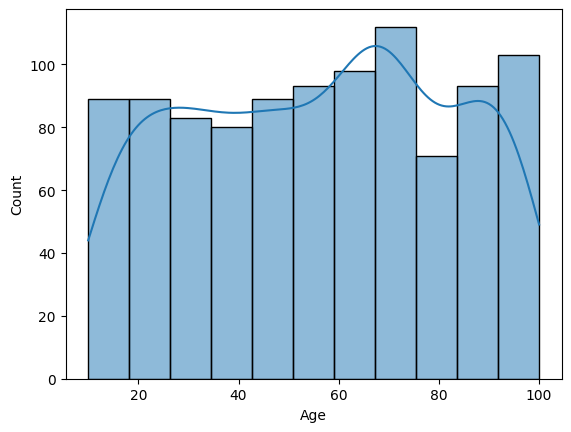

In [11]:
sns.histplot(df['Age'],kde=True)

In [12]:
df['Age'].skew()

np.float64(-0.06715780729591238)

<Axes: xlabel='Heart Rate', ylabel='Count'>

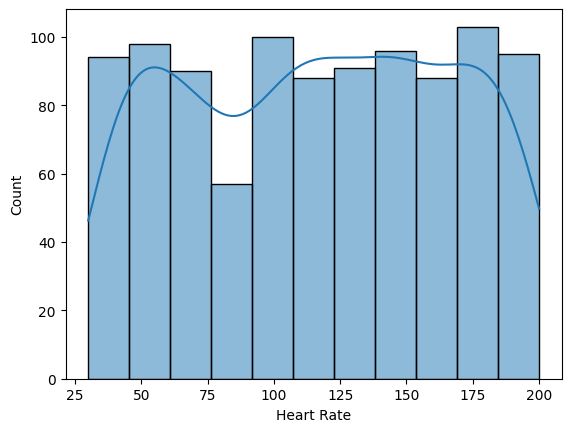

In [13]:
sns.histplot(df['Heart Rate'],kde=True)

['Walking', 'Running', 'Resting', 'Driving', 'Swimming']

<Axes: xlabel='Sleep Score', ylabel='Count'>

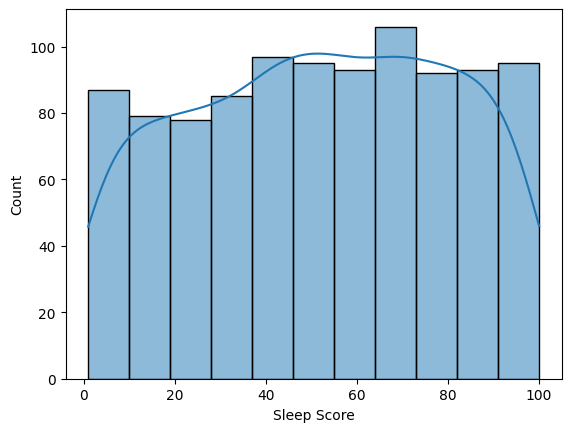

In [14]:
sns.histplot(df['Sleep Score'],kde=True)

['Sunny', 'Rainy', 'Cold']

In [15]:
df['Age'].skew()

np.float64(-0.06715780729591238)

In [16]:
df['Heart Rate'].skew()

np.float64(-0.05066725445650137)

## Countplot 

<Axes: ylabel='count'>

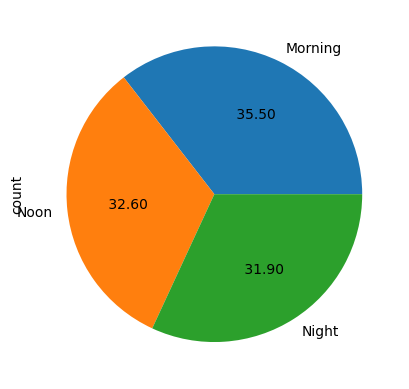

In [17]:
df['Time of Day'].value_counts().plot(kind="pie", autopct="% .2f")

<Axes: ylabel='count'>

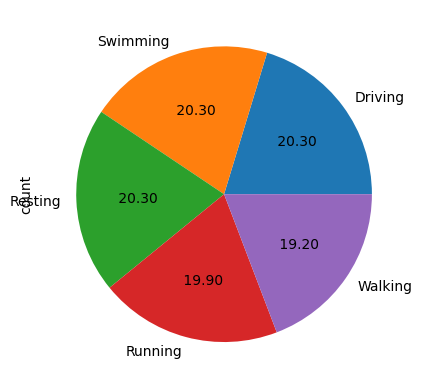

In [18]:
df['Activity'].value_counts().plot(kind="pie", autopct="% .2f")

<Axes: ylabel='count'>

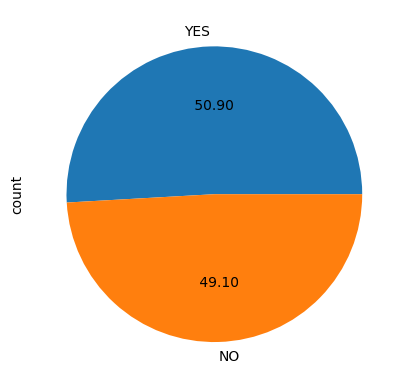

In [19]:
df['Recent Events'].value_counts().plot(kind="pie", autopct="% .2f")

<Axes: ylabel='count'>

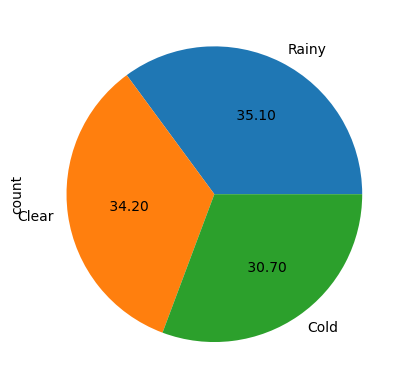

In [20]:
df['Weather'].value_counts().plot(kind="pie", autopct="% .2f")

### Split data for input and output

In [21]:
X=df.iloc[:,0:9]
X.shape

(1000, 9)

In [22]:
X.head()

,Time of Day,Activity,Age,Heart Rate,Weather,Day of Week,Recent Events,Battery Status,Sleep Score
0,Night,Running,15,175,Rainy,Weekday,YES,50,4
1,Morning,Running,98,161,Rainy,Holiday,YES,20,93
2,Night,Driving,48,46,Rainy,Holiday,NO,55,41
3,Night,Walking,69,43,Cold,Weekday,YES,81,45
4,Morning,Resting,37,42,Clear,Weekday,NO,2,50


In [23]:
y=df.iloc[:, 9:21]
y.head()

,Daily Activity,Sleep,Running,Swimming,Calories Burn,Heart Rate (show),Steps,Consumed,Weather (show),Chance of Rain,Events,Battery
0,1,1,1,0,1,1,1,0,1,1,1,0
1,1,0,1,0,1,1,1,0,1,1,1,0
2,1,1,0,0,0,1,0,0,1,1,0,0
3,1,1,0,0,1,1,1,0,1,0,1,0
4,0,1,0,0,0,1,0,0,0,0,0,1


In [24]:
y.head()

,Daily Activity,Sleep,Running,Swimming,Calories Burn,Heart Rate (show),Steps,Consumed,Weather (show),Chance of Rain,Events,Battery
0,1,1,1,0,1,1,1,0,1,1,1,0
1,1,0,1,0,1,1,1,0,1,1,1,0
2,1,1,0,0,0,1,0,0,1,1,0,0
3,1,1,0,0,1,1,1,0,1,0,1,0
4,0,1,0,0,0,1,0,0,0,0,0,1


### Split train and test data

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
X_train.shape

(800, 9)

In [27]:
y_train.shape

(800, 12)

In [28]:
X_test.shape

(200, 9)

### Feature Engineering

In [29]:
columnTransformer = ColumnTransformer(transformers=[
    ('tnf1', OneHotEncoder(sparse_output=False),['Time of Day','Activity','Weather','Day of Week']),
    ('tnf2', OrdinalEncoder(categories=[['YES','NO']]),['Recent Events']),
    ('tnf3', StandardScaler(), ['Age']),
    ('tnf4', MinMaxScaler(), ['Heart Rate','Sleep Score', 'Battery Status'])
],remainder='passthrough')

In [30]:
columnTransformer.set_output(transform='pandas')

,transformers,"[('tnf1', ...), ('tnf2', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,None
,sparse_output,False


In [31]:
X_train_transformed = columnTransformer.fit_transform(X_train)

In [32]:
ordinal_encoder = columnTransformer.transformers_[1][1]
ordinal_mappings = ordinal_encoder.categories_
print("Ordinal Encoder mappings: ", ordinal_mappings)

Ordinal Encoder mappings:  [array(['YES', 'NO'], dtype=object)]


In [33]:
onehot_encoder = columnTransformer.transformers_[0][1]
onhot_categories = onehot_encoder.categories_
print("OneHotEncoder categories: ", onhot_categories)

OneHotEncoder categories:  [array(['Morning', 'Night', 'Noon'], dtype=object), array(['Driving', 'Resting', 'Running', 'Swimming', 'Walking'],
      dtype=object), array(['Clear', 'Cold', 'Rainy'], dtype=object), array(['Holiday', 'Weekday'], dtype=object)]


In [34]:
standard_scaler = columnTransformer.transformers_[2][1]

standard_mean = standard_scaler.mean_
standard_scale = standard_scaler.scale_

print("Standard Scaler mean:", standard_mean)
print('Standard Scaler scale: ', standard_scale)

Standard Scaler mean: [55.805]
Standard Scaler scale:  [25.98272455]


In [35]:
minmax_scaler = columnTransformer.transformers_[3][1]

minmax_mean = minmax_scaler.min_
minmax_scale = minmax_scaler.scale_

print("Minmax Scaler min:", minmax_mean)
print('Minmax Scaler scale: ', minmax_scale)

Minmax Scaler min: [-0.17647059 -0.01010101 -0.01010101]
Minmax Scaler scale:  [0.00588235 0.01010101 0.01010101]


In [36]:
X_train_transformed.head()

,tnf1__Time of Day_Morning,tnf1__Time of Day_Night,tnf1__Time of Day_Noon,tnf1__Activity_Driving,tnf1__Activity_Resting,tnf1__Activity_Running,tnf1__Activity_Swimming,tnf1__Activity_Walking,tnf1__Weather_Clear,tnf1__Weather_Cold,tnf1__Weather_Rainy,tnf1__Day of Week_Holiday,tnf1__Day of Week_Weekday,tnf2__Recent Events,tnf3__Age,tnf4__Heart Rate,tnf4__Sleep Score,tnf4__Battery Status
29,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,-1.531979,0.288235,0.030303,0.343434
535,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,-1.147108,0.705882,0.525253,0.282828
695,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,-0.184931,0.241176,0.262626,0.696970
557,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,-0.261905,0.311765,0.636364,0.818182
836,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.585477,0.894118,0.727273,0.090909


In [37]:
X_test_transformed = columnTransformer.transform(X_test)

In [38]:
X_train_transformed.shape

(800, 18)

In [39]:
X_test_transformed.head()

,tnf1__Time of Day_Morning,tnf1__Time of Day_Night,tnf1__Time of Day_Noon,tnf1__Activity_Driving,tnf1__Activity_Resting,tnf1__Activity_Running,tnf1__Activity_Swimming,tnf1__Activity_Walking,tnf1__Weather_Clear,tnf1__Weather_Cold,tnf1__Weather_Rainy,tnf1__Day of Week_Holiday,tnf1__Day of Week_Weekday,tnf2__Recent Events,tnf3__Age,tnf4__Heart Rate,tnf4__Sleep Score,tnf4__Battery Status
521,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.585477,0.394118,0.919192,0.545455
737,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,-1.224083,0.988235,0.444444,0.070707
740,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.046657,0.658824,0.646465,0.626263
660,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.623299,0.082353,0.797980,0.434343
411,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.546325,0.311765,0.161616,0.545455


#### Model construction

In [40]:
model = MultiOutputClassifier(RandomForestClassifier(n_estimators=200, max_depth=10, max_features="sqrt", min_samples_split=5,random_state=42,class_weight=None, n_jobs=-1), n_jobs=-1)

In [41]:
model.fit(X_train_transformed, y_train)

,estimator,RandomForestC...ndom_state=42)
,n_jobs,-1
,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0


In [42]:
y_predict = model.predict(X_test_transformed)

In [43]:
import numpy as np
test_sample = np.array([['Night', 'Resting', 30, 70, 'Cold', 'Holiday', 'NO', 19, 80]])
data = {
    'Time of Day': ['Night'], 
    'Activity': ['Resting'], 
    'Age': [30],
    'Heart Rate': [70],
    'Weather': ['Cold'],
       'Day of Week': ['Holiday'],
       'Recent Events': ['NO'],
        'Battery Status': [19],
       'Sleep Score': [80]
       }
# print(col_names)
test_sample_df = pd.DataFrame(data)
# print(test_sample_df)
test_sample_transformed = columnTransformer.transform(test_sample_df)
# test_sample_transformed
output_sample = model.predict(test_sample_transformed)
test_sample_transformed
# output_sample


,tnf1__Time of Day_Morning,tnf1__Time of Day_Night,tnf1__Time of Day_Noon,tnf1__Activity_Driving,tnf1__Activity_Resting,tnf1__Activity_Running,tnf1__Activity_Swimming,tnf1__Activity_Walking,tnf1__Weather_Clear,tnf1__Weather_Cold,tnf1__Weather_Rainy,tnf1__Day of Week_Holiday,tnf1__Day of Week_Weekday,tnf2__Recent Events,tnf3__Age,tnf4__Heart Rate,tnf4__Sleep Score,tnf4__Battery Status
0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,-0.99316,0.235294,0.79798,0.181818


In [44]:

sample = model.predict(np.array([[0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,-0.99316,0.235294,0.79798,0.181818]], dtype=np.float32))
sample

array([[0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1]])

In [45]:
accuracy_score(y_test, y_predict)

0.995

In [46]:
(1 - hamming_loss(y_test, y_predict)) * 100

99.95833333333334

In [47]:
f1_score(y_test, y_predict, average='micro')

0.9995311767463666

In [48]:
f1_score(y_test, y_predict, average='macro')

0.9997435897435897

In [49]:
accuracy_scorer = make_scorer(hamming_loss)

In [50]:
# import joblib
# import sys

# model_path = sys.path[9] + "models"
# joblib.dump(columnTransformer , model_path)
# joblib.dump(model, model_path)
import pickle
from sklearn.pipeline import Pipeline


with open('../models/synthetic_data/columnTransfer.pkl', 'wb') as files:
    pickle.dump(columnTransformer, files)
    
with open('../models/synthetic_data/model.pkl', 'wb') as files:
    pickle.dump(model, files)

pipeline = Pipeline([
            ('preprocessor', columnTransformer),
            ('model', model)
        ])


pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
print(y_pred)

with open("../models/synthetic_data/pipeline_from_notebook.pkl", "wb") as f:
            pickle.dump(pipeline, f)



[[1 0 0 ... 1 1 0]
 [1 1 0 ... 0 0 1]
 [1 0 0 ... 0 1 0]
 ...
 [1 0 0 ... 0 1 0]
 [1 0 1 ... 0 1 0]
 [1 1 0 ... 0 1 0]]


In [51]:
with open("../models/synthetic_data/pipeline_from_notebook.pkl", "rb") as f:
            loaded_model = pickle.load(f)
            
y_pred = loaded_model.predict(X_test)
print(y_pred)

[[1 0 0 ... 1 1 0]
 [1 1 0 ... 0 0 1]
 [1 0 0 ... 0 1 0]
 ...
 [1 0 0 ... 0 1 0]
 [1 0 1 ... 0 1 0]
 [1 1 0 ... 0 1 0]]


In [52]:
import skl2onnx
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType


# with open("../models/synthetic_data/model.pkl", "rb") as f:
#             loaded_main_model = pickle.load(f)

# pipeline_temp = Pipeline([("multi_output", model)])

# print("Model Type:", type(pipeline_temp))

input_shape = FloatTensorType([None, 18])

onnx_model = convert_sklearn(model, initial_types=[("input", input_shape)])

with open("../models/synthetic_data/model.onnx", "wb") as f:
    f.write(onnx_model.SerializeToString())

e:\Work\ML\Context-Aware-Widget-Recommendation\venv\lib\site-packages\skl2onnx\_parse.py:582: UserWarning: Option zipmap is ignored for model <class 'sklearn.multioutput.MultiOutputClassifier'>. Set option zipmap to False to remove this message.
  warnings.warn(


In [53]:
import onnx
import onnxruntime as ort
import numpy as np

loaded_onnx_model = onnx.load("../models/synthetic_data/model.onnx")
# onnx.checker.check_model(loaded_model)

ort_session = ort.InferenceSession("../models/synthetic_data/model.onnx")



# input_data = np.random.rand(1, 13).astype(np.float32)
input_data = np.array([[0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,-0.99316,0.235294,0.79798,0.181818]], dtype=np.float32)
outputs = ort_session.run(None, {"input": input_data})
for output in ort_session.get_outputs():
    print("Output Name: ", output.name, "Shape: ", output.shape)

predictions = [np.argmax(output, axis=1) for output in outputs]
# final = np.column_stack(predictions)

print("onnx output: ", outputs) # array([[0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1]])

Output Name:  label Shape:  [None, 12]
Output Name:  probabilities Shape:  []
onnx output:  [array([[0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1]]), [array([[0.9776701 , 0.02232993]], dtype=float32), array([[0.94251645, 0.05748356]], dtype=float32), array([[0.995, 0.005]], dtype=float32), array([[0.98754764, 0.01245238]], dtype=float32), array([[0.99376374, 0.00623625]], dtype=float32), array([[0.75143677, 0.24856322]], dtype=float32), array([[0.995, 0.005]], dtype=float32), array([[0.04703856, 0.95296144]], dtype=float32), array([[0.0121749, 0.9878251]], dtype=float32), array([[0.99777776, 0.00222222]], dtype=float32), array([[0.9074268 , 0.09257324]], dtype=float32), array([[0.12632138, 0.8736786 ]], dtype=float32)]]


In [54]:
k_fold= KFold(n_splits=5, shuffle=True, random_state=42)

In [55]:
cross_val_scores = cross_validate(model, X_train_transformed, y_train, cv=k_fold, scoring=accuracy_scorer, return_train_score=False)

In [56]:
(1 - cross_val_scores['test_score'].mean()) * 100

np.float64(99.95833333333334)

#### Grid Search CV

In [57]:
param_grid = {'estimator__n_estimators': [15, 20, 30, 40],
              'estimator__max_features': [0.2, 0.6, "sqrt"],
              'estimator__max_depth': [2, 6, 8, 10],
              'estimator__max_samples': [0.5, 0.75, 1.0],
              'estimator__min_samples_split': [2,5],
              'estimator__class_weight': ["balanced", None]
             }

In [58]:
rf = RandomForestClassifier(random_state=42)

In [59]:
multi_rf =MultiOutputClassifier(rf)

In [60]:
rfGridSearchCV = GridSearchCV(model, param_grid= param_grid, cv=3, scoring=hamming_loss, n_jobs= -1)

In [61]:
rfGridSearchCV.fit(X_train_transformed, y_train)

e:\Work\ML\Context-Aware-Widget-Recommendation\venv\lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan n

,estimator,MultiOutputCl... n_jobs=-1)
,param_grid,"{'estimator__class_weight': ['balanced', None], 'estimator__max_depth': [2, 6, ...], 'estimator__max_features': [0.2, 0.6, ...], 'estimator__max_samples': [0.5, 0.75, ...], ...}"
,scoring,<function ham...00243EF02ECB0>
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,15


In [62]:
rfGridSearchCV.best_score_

np.float64(nan)

In [63]:
rfGridSearchCV.best_params_

{'estimator__class_weight': 'balanced',
 'estimator__max_depth': 2,
 'estimator__max_features': 0.2,
 'estimator__max_samples': 0.5,
 'estimator__min_samples_split': 2,
 'estimator__n_estimators': 15}

In [64]:
n_estimators = 15
max_depth = 2

In [65]:
mlflow.set_experiment("Multi_Label_Classification_Monitoring")


2026/06/27 14:16:50 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/27 14:16:50 INFO mlflow.store.db.utils: Updating database tables
2026/06/27 14:16:50 INFO mlflow.tracking.fluent: Experiment with name 'Multi_Label_Classification_Monitoring' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:///e:/Work/ML/Context-Aware-Widget-Recommendation/notebooks/mlruns/1', creation_time=1782548210809, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1782548210809, lifecycle_stage='active', name='Multi_Label_Classification_Monitoring', tags={}, trace_location=None, workspace='default'>

In [66]:
model = MultiOutputClassifier(RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, max_features="sqrt", min_samples_split=2,random_state=42,class_weight=None, n_jobs=-1), n_jobs=-1)

In [67]:
model.fit(X_train_transformed, y_train)

,estimator,RandomForestC...ndom_state=42)
,n_jobs,-1
,n_estimators,15
,criterion,'gini'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0


In [68]:
y_predict = model.predict(X_test_transformed)

In [69]:
accuracy = accuracy_score(y_test, y_predict)
h_loss = hamming_loss(y_test, y_predict)
f1_macro = f1_score(y_test, y_predict, average='macro')

In [78]:
if mlflow.active_run():
    mlflow.end_run()
mlflow.set_experiment("Multi_Label_Classification_Monitoring")
with mlflow.start_run(run_name="Notebook_Random_Forest_MultiOutput"):
    mlflow.log_param("n_estimators", n_estimators)
    mlflow.log_param("max_depth", max_depth)
    mlflow.log_param("classifier_type", "RandomForest")
    mlflow.log_metric("exact_match_accuracy", accuracy)
    mlflow.log_metric("hamming_loss", h_loss)
    mlflow.log_metric("f1_score_macro", f1_macro)
    mlflow.sklearn.log_model(
    sk_model=model, 
    artifact_path="widget_prediction_pipeline"
    )

2026/06/27 14:24:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
